# Methodology 1  Propagation effects

**Q1 — Contagion / knock-on propagation.** When a service is disrupted, how much extra delay is passed to the next service.

**Which delay variable** The propagation analysis uses departure delay, because the contagion mechanism is mechanical: a late inbound trainset compresses the turnaround and pushes out the next departure.

In [13]:
# ── Setup ───────────────────────────────────────────────────────────────
import sys, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

SEED = 42; np.random.seed(SEED)
TARGET_NPS = 0.38
DISRUPT = 5.0            
TRIGGER = 15.0          
print(sys.version)
df = pd.read_parquet("Data/final_data.parquet")
print(f"Passenger rows: {len(df):,} | services: {df['service_id'].nunique():,}")

3.9.6 (default, Nov 11 2024, 03:15:38) 
[Clang 16.0.0 (clang-1600.0.26.6)]
Passenger rows: 169,480 | services: 36,511


## 1. Re-estimate the two models 

Both the satisfaction model (aggregated delay → NPS) and the operational delay model are re-estimated on the service-level sample, as in the main methodology.

In [14]:
# ── Service-level frame + both models ───────────────────────────────────
keep = ['Aggregated NPS','Aggregated Delay','Departure Delay','Arrival Delay',
        'Theoretical Rotation Time','total_fleet_reliability','total_ordered_departures',
        'metadata_departure_date','metadata_departure_hour','route_type']
keep = [c for c in keep if c in df.columns]
n_resp = df.groupby('service_id').size().rename('n_responses')
svc = pd.concat([df.groupby('service_id')[keep].first(), n_resp], axis=1).reset_index()
svc = svc[svc['n_responses'] >= 2]
svc = svc[(svc['Aggregated Delay'] >= -60) & (svc['Aggregated Delay'] <= 600)]
svc = svc[(svc['Theoretical Rotation Time'] > 0) & (svc['Theoretical Rotation Time'] <= 480)]

m = svc.rename(columns={'Aggregated NPS':'agg_nps','Aggregated Delay':'agg_delay',
    'Departure Delay':'dep_delay','Arrival Delay':'arr_delay','Theoretical Rotation Time':'T',
    'total_fleet_reliability':'R','total_ordered_departures':'F','route_type':'route'}).copy()
m = m.dropna(subset=['agg_nps','agg_delay','F','R','T','route','n_responses'])

sat = smf.wls('agg_nps ~ agg_delay', data=m, weights=m['n_responses']).fit(cov_type='HC3')
b0, b1 = sat.params['Intercept'], sat.params['agg_delay']
op  = smf.ols('agg_delay ~ F + R + T + F:R + C(route)', data=m).fit(cov_type='HC3')
nps = lambda d: b0 + b1*d
print(f"Satisfaction:  AggNPS = {b0:.4f} + ({b1:.5f}) * agg_delay   [target {TARGET_NPS}]")
print(f"  -> +1 min of (aggregated) delay changes AggNPS by {b1:.5f}")

Satisfaction:  AggNPS = 0.4275 + (-0.00299) * agg_delay   [target 0.38]
  -> +1 min of (aggregated) delay changes AggNPS by -0.00299


## 2. Propagation decay 

The departure delay is used not aggregated delay since aggregated delay would fold in each later service's own arrival delay, which is driven by its own en-route conditions and is largely unrelated to the original trigger.

Services on each day are ordered by departure hour, a disrupted departure (>15 min) is treated as the trigger, and the excess departure delay of the services that follow is measured at each later lag against the punctual counterfactual. 

 lag  after_disruption  after_punctual  excess_dep_delay    se
   1            21.297          17.102             4.195 0.461
   2            19.682          18.414             1.269 0.467
   3            20.780          17.546             3.234 0.476
   4            21.175          17.069             4.106 0.484
   5            21.256          17.088             4.168 0.493
   6            21.221          17.054             4.166 0.505
   7            20.765          17.376             3.389 0.514
   8            20.685          17.309             3.375 0.524

Propagation stays material for ~8 service(s) after a disruption (contiguous reach).


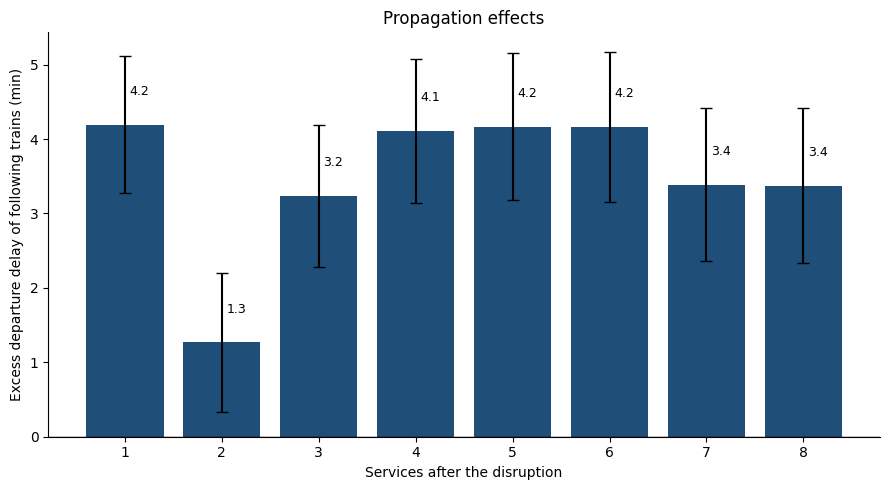

Total contagion footprint (contiguous chain): 27.9 departure-delay min


In [15]:
# ── Impulse response: ARRIVAL-delay trigger -> DEPARTURE-delay response ──
# Mechanism: a disruption strikes EN ROUTE (late arrival of the inbound trainset),
# which compresses the next turnaround and pushes out the FOLLOWING departure(s).
# Trigger is therefore measured on arrival delay; the propagated response is measured
# on the departure delay of the trains behind it.
def parse_hour(x):
    if pd.isna(x): return np.nan
    mt = re.search(r'(\d{1,2})', str(x)); return int(mt.group(1)) if mt else np.nan
m['dep_hour'] = m['metadata_departure_hour'].apply(parse_hour)
m['date'] = pd.to_datetime(m['metadata_departure_date'], errors='coerce')

seq = m.dropna(subset=['dep_hour','date','arr_delay','dep_delay']).sort_values(['date','dep_hour']).copy()
K = 8
for k in range(1, K+1):
    seq[f'lead{k}'] = seq.groupby('date')['dep_delay'].shift(-k)   # DEPARTURE delay k trains later
seq['trigger'] = seq['arr_delay'] > TRIGGER                        # disruption seen as a late ARRIVAL

rows=[]
for k in range(1, K+1):
    sub = seq.dropna(subset=[f'lead{k}'])
    a = sub.loc[sub['trigger'],  f'lead{k}']
    b = sub.loc[~sub['trigger'], f'lead{k}']
    rows.append({'lag':k,'after_disruption':a.mean(),'after_punctual':b.mean(),
                 'excess_dep_delay':a.mean()-b.mean(),
                 'se':np.sqrt(a.var()/len(a)+b.var()/len(b))})
decay = pd.DataFrame(rows)
print(decay.round(3).to_string(index=False))

# contiguous reach from lag 1: stop at the first lag that is not clearly positive
reach = 0
for _, r in decay.iterrows():
    if (r['excess_dep_delay'] > 1.0) and (r['excess_dep_delay'] > 2*r['se']):
        reach = int(r['lag'])
    else:
        break
print(f"\nPropagation stays material for ~{reach} service(s) after a disruption (contiguous reach).")

fig, ax = plt.subplots(figsize=(9,5))
colors = ['#1f4e79' if r['lag']<=max(reach,1) else '#9FB0CE' for _,r in decay.iterrows()]
ax.bar(decay['lag'], decay['excess_dep_delay'], yerr=2*decay['se'], capsize=4, color=colors)
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('Services after the disruption')
ax.set_ylabel('Excess departure delay of following trains (min)')
ax.set_title('Propagation effects')
for _,r in decay.iterrows():
    ax.text(r['lag'] +0.15, r['excess_dep_delay']+0.4, f"{r['excess_dep_delay']:.1f}", ha='center', fontsize=9)
ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

# footprint over the contiguous chain, converted to NPS ONCE
footprint_min = decay[decay['lag']<=max(reach,1)]['excess_dep_delay'].clip(lower=0).sum()
footprint_nps = b1*footprint_min      # propagated departure min flow ~1:1 into aggregated delay
print(f"Total contagion footprint (contiguous chain): {footprint_min:.1f} departure-delay min")
